In [ ]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.cluster import KMeans
from sklearn.neural_network import MLPClassifier
from sklearn.manifold import TSNE
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    RocCurveDisplay,
    ConfusionMatrixDisplay,
    f1_score
)

In [ ]:
table = pd.read_csv('A1 - global_store.csv')
table['returned'] = (table['returned'] == 'Yes').astype(int)

In [ ]:
table['order_date'] = pd.to_datetime(table['order_date'], format='%d/%m/%Y')
table['shipping_date'] = pd.to_datetime(table['shipping_date'], format='%d/%m/%Y')

table['shipping_delay'] = (table['shipping_date'] - table['order_date']).map(lambda each: each.days)

In [ ]:
table['avg_item_price'] = table['sales'] / table['quantity']

In [ ]:
def fill_cat_mean(table, colname):
    stats = table.groupby(by=[colname])[['returned']].mean().reset_index()
    stats.rename(columns={'returned': f'return_ratio_{colname}'}, inplace=True)
    return pd.merge(left=table, right=stats, on=colname, how='left')

In [ ]:
keep_columns = ['sales', 'discount', 'profit', 'shipping_cost', 'returned']
convert_to_mean = ['shipping_mode', 'customer_id', 'segment', 'city', 'region', 'product_id', 'category', 'sub_category']

for each in convert_to_mean:
    table = fill_cat_mean(table, each)
    keep_columns.append(f'return_ratio_{each}')

In [ ]:
for each in ['sales', 'profit', 'shipping_cost']:
    table[each] = (table[each] - table[each].min()) / (table[each].max() - table[each].min())

In [ ]:
feature_col = keep_columns.copy()
feature_col.remove('returned')
target_col = 'returned'

feature = table[feature_col]
target = table[target_col]

In [ ]:
train_feature, test_feature, train_target, test_target = train_test_split(feature, target, train_size=0.75, shuffle=True)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1196: UserWarning: l1_ratio parameter is only used when penalty is 'elasticnet'. Got (penalty=l2)
  warnings.warn(


0.6244284781188766


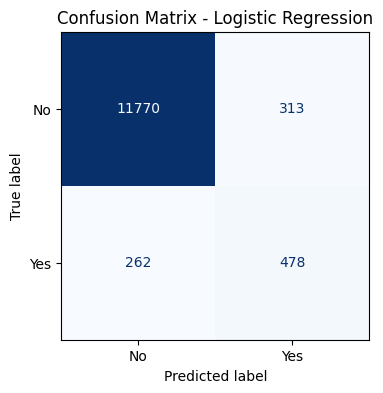

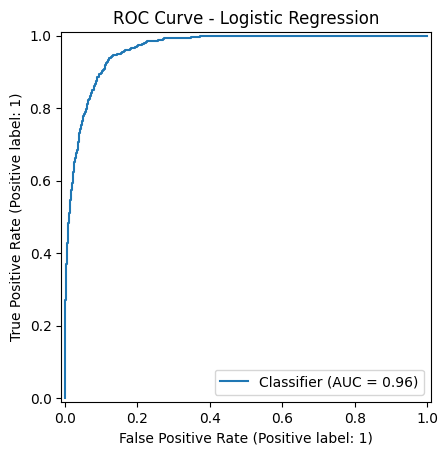

In [ ]:
model = LogisticRegression(max_iter=100_000, n_jobs=-1, tol=1e-8, C=100, l1_ratio=0.1, class_weight={0:1, 1:2.5})
model.fit(train_feature, train_target)
pred = model.predict_proba(test_feature)[:,1]
print(f1_score(pred>0.5, test_target))
CM_LR = confusion_matrix(test_target, (pred>0.5)*1)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=CM_LR, display_labels=["No", "Yes"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

RocCurveDisplay.from_predictions(test_target, pred)
plt.title("ROC Curve - Logistic Regression")
plt.show()

In [ ]:
importance = [(name, value) for name, value in zip(train_feature, model.coef_[0])]
importance.sort(key=lambda each: each[1], reverse=True)
importance

[('return_ratio_customer_id', np.float64(12.257598498211516)),
 ('return_ratio_product_id', np.float64(12.099126554818161)),
 ('return_ratio_shipping_mode', np.float64(11.181762741008395)),
 ('return_ratio_city', np.float64(8.710275395265864)),
 ('return_ratio_region', np.float64(3.783773924799202)),
 ('profit', np.float64(1.556695346809409)),
 ('shipping_cost', np.float64(1.0408537456440488)),
 ('discount', np.float64(0.22383809147442094)),
 ('return_ratio_segment', np.float64(-1.108457615997567)),
 ('sales', np.float64(-2.5873576306654447)),
 ('return_ratio_category', np.float64(-2.95526656607183)),
 ('return_ratio_sub_category', np.float64(-8.43396192023893))]

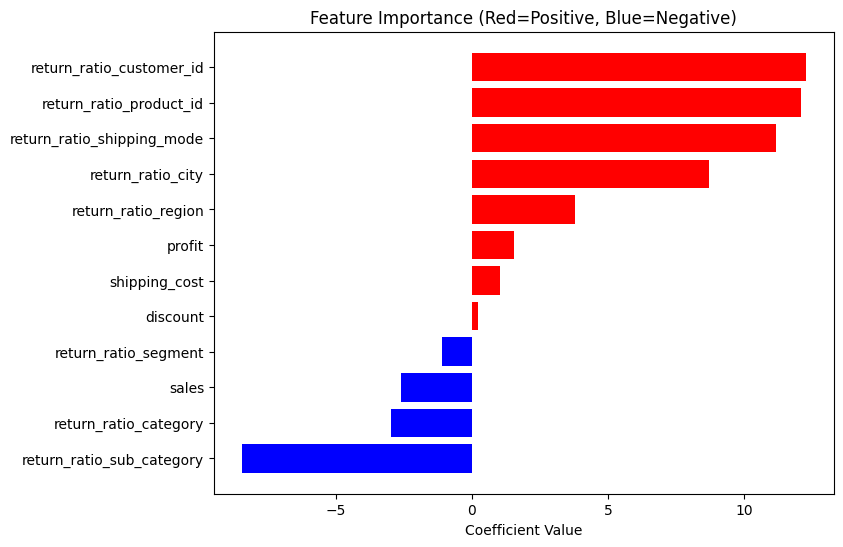

In [ ]:
names = [each[0] for each in importance]
values = [each[1] for each in importance]

colors = ['red' if v > 0 else 'blue' for v in values]

plt.figure(figsize=(8,6))
plt.barh(names, values, color=colors)
plt.gca().invert_yaxis()
plt.xlabel("Coefficient Value")
plt.title("Feature Importance (Red=Positive, Blue=Negative)")
plt.show()

In [ ]:
mlp = MLPClassifier(
    hidden_layer_sizes=(128, 128, 32),
    activation='relu',
    solver='sgd',
    learning_rate_init=1e-3,
    max_iter=200,
    batch_size=128,
    early_stopping=False,
    verbose=True,
)

mlp.fit(train_feature, train_target)

Iteration 1, loss = 0.32528670
Iteration 2, loss = 0.21891098
Iteration 3, loss = 0.21362085
Iteration 4, loss = 0.20757363
Iteration 5, loss = 0.20032146
Iteration 6, loss = 0.19125967
Iteration 7, loss = 0.18024395
Iteration 8, loss = 0.16727767
Iteration 9, loss = 0.15338502
Iteration 10, loss = 0.14193679
Iteration 11, loss = 0.13336684
Iteration 12, loss = 0.12709056
Iteration 13, loss = 0.12271581
Iteration 14, loss = 0.11952313
Iteration 15, loss = 0.11731847
Iteration 16, loss = 0.11593035
Iteration 17, loss = 0.11460528
Iteration 18, loss = 0.11370821
Iteration 19, loss = 0.11301180
Iteration 20, loss = 0.11213899
Iteration 21, loss = 0.11161612
Iteration 22, loss = 0.11092278
Iteration 23, loss = 0.11048426
Iteration 24, loss = 0.10997568
Iteration 25, loss = 0.10960999
Iteration 26, loss = 0.10924257
Iteration 27, loss = 0.10899175
Iteration 28, loss = 0.10866941
Iteration 29, loss = 0.10839998
Iteration 30, loss = 0.10824384
Iteration 31, loss = 0.10790546
Iteration 32, los

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


MLPClassifier(batch_size=128, hidden_layer_sizes=(128, 128, 32), solver='sgd',
              verbose=True)

In [ ]:
mlp_pred = mlp.predict_proba(test_feature)[:,1]

0.6691285081240768


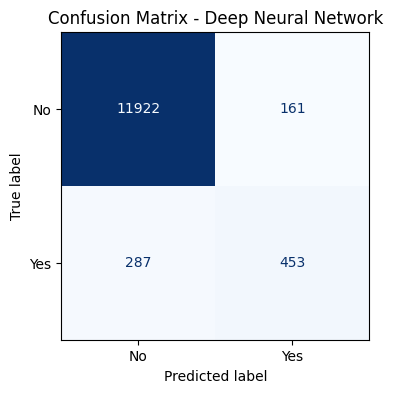

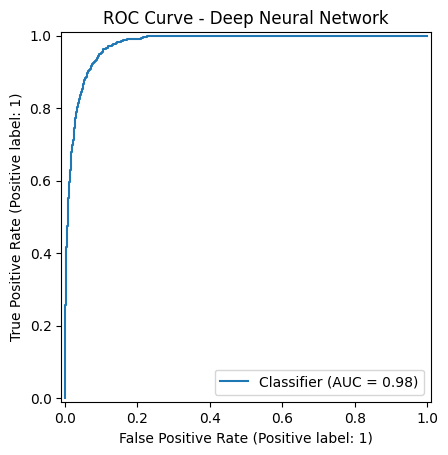

In [ ]:
print(f1_score(mlp_pred>0.5, test_target))
CM_LR = confusion_matrix(test_target, (mlp_pred>0.5)*1)
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=CM_LR, display_labels=["No", "Yes"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix - Deep Neural Network")
plt.show()

RocCurveDisplay.from_predictions(test_target, mlp_pred)
plt.title("ROC Curve - Deep Neural Network")
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

lr_pred_label = (pred > 0.5).astype(int)

lr_metrics = {
    "Accuracy": accuracy_score(test_target, lr_pred_label),
    "Precision": precision_score(test_target, lr_pred_label),
    "Recall": recall_score(test_target, lr_pred_label),
    "F1 Score": f1_score(test_target, lr_pred_label),
    "ROC-AUC": roc_auc_score(test_target, pred)
}

mlp_pred_label = (mlp_pred > 0.5).astype(int)

mlp_metrics = {
    "Accuracy": accuracy_score(test_target, mlp_pred_label),
    "Precision": precision_score(test_target, mlp_pred_label),
    "Recall": recall_score(test_target, mlp_pred_label),
    "F1 Score": f1_score(test_target, mlp_pred_label),
    "ROC-AUC": roc_auc_score(test_target, mlp_pred)
}

comparison_df = pd.DataFrame([lr_metrics, mlp_metrics], index=["Logistic Regression", "Deep Neural Network"])

print("Model Comparison:")
display(comparison_df)

Model Comparison:


,Accuracy,Precision,Recall,F1 Score,ROC-AUC
Logistic Regression,0.955159,0.604298,0.645946,0.624428,0.964732
Deep Neural Network,0.965063,0.737785,0.612162,0.669129,0.977709


In [ ]:
import zipfile, io
import numpy as np
import torch
from torchvision import models, transforms
from PIL import Image
from tqdm.notebook import tqdm

zip_path = "A1 - product_images.zip"

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],[0.229, 0.224, 0.225]),
])

model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
model = torch.nn.Sequential(*list(model.children())[:-1])
model.eval()

features = []

with zipfile.ZipFile(zip_path) as z:
    for name in tqdm(z.namelist()):
        if name.lower().endswith((".jpg", ".png", ".jpeg")):
            img = Image.open(io.BytesIO(z.read(name))).convert("RGB")
            img = transform(img).unsqueeze(0)
            with torch.no_grad():
                features.append(model(img).squeeze().numpy())

features = np.stack(features)
print(features.shape)

  0%|          | 0/2400 [00:00<?, ?it/s]

(2400, 2048)


In [ ]:
kmeans = KMeans(n_clusters=2, random_state=42).fit(features)
centers = kmeans.cluster_centers_

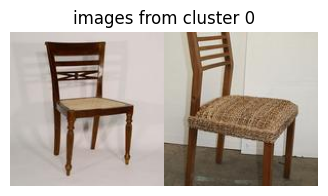

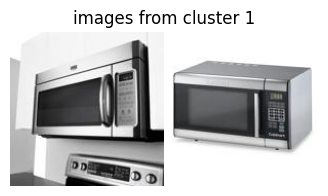

In [ ]:
import zipfile, io
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

idx = {}
k = 2
zip_path = "A1 - product_images.zip"

with zipfile.ZipFile(zip_path) as z:
    fnames = sorted([n for n in z.namelist() if n.lower().endswith((".jpg", ".jpeg", ".png", ".webp"))])

    for center_idx, each_center in enumerate(kmeans.cluster_centers_):
        distance = np.linalg.norm(features - each_center, axis=1)
        idx[center_idx] = [fnames[i] for i in np.argpartition(distance, k)[:k]]

        images = []
        for each in idx[center_idx]:
            img = Image.open(io.BytesIO(z.read(each))).convert("RGB")
            images.append(np.array(img))

        plt.figure(figsize=(5, 2))
        plt.imshow(np.concatenate(images, axis=1))
        plt.title(f'images from cluster {center_idx}')
        plt.axis('off')
        plt.show()

Based on the visual analysis of the images within the clusters:

Cluster 0 appears to represent smaller, more portable office supplies and general household items, such as staplers, tape dispensers, scissors, and small containers.
Cluster 1 seems to contain larger furniture and office equipment, including items like chairs, desks, bookshelves, and filing cabinets.
Therefore, the K-Means clustering algorithm has effectively grouped products based on their physical size and potentially their function, separating smaller, individual items from larger furniture or equipment pieces.